<a href="https://colab.research.google.com/github/Najla-Nuricia/PCVK26_19_Najla/blob/main/Praktikum_week6_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
Nama = 'Najla Nuricia Laudy'
NIM = '244107020091'

print(Nama, NIM)

Najla Nuricia Laudy 244107020091


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [7]:
def convolution2d(image, kernel, stride, padding):
    # Tambahkan padding pada image
    padded_image = np.pad(
        image,
        ((padding, padding), (padding, padding)),
        mode='constant'
    )

    image_h, image_w = padded_image.shape
    kernel_h, kernel_w = kernel.shape

    # Ukuran output
    output_h = (image_h - kernel_h) // stride + 1
    output_w = (image_w - kernel_w) // stride + 1

    output = np.zeros((output_h, output_w))

    for i in range(0, output_h):
        for j in range(0, output_w):
            row = i * stride
            col = j * stride
            region = padded_image[
                row:row + kernel_h,
                col:col + kernel_w
            ]
            output[i, j] = np.sum(region * kernel)

    return output

In [8]:
img = cv.imread('/content/drive/MyDrive/coolyeah /PCVK/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

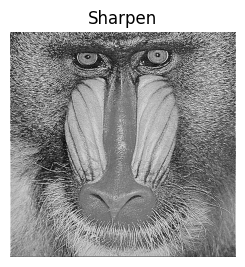

In [13]:
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

hasil_sharpen = convolution2d(
    img_gray,
    kernel_sharpen,
    1,
    1
)

hasil_sharpen = np.clip(hasil_sharpen, 0, 255).astype(np.uint8)

plt.subplot(1, 2, 2)
plt.imshow(hasil_sharpen, cmap="gray")
plt.title("Sharpen")
plt.axis("off")

plt.show()

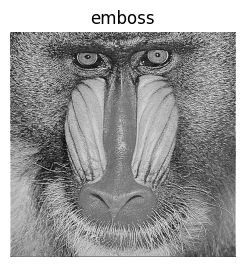

In [14]:
kernel_emboss = np.array([
    [-2, -1, 0],
    [-1, 1, 1],
    [0, 1, 2]
])

hasil_emboss = convolution2d(
    img_gray,
    kernel_emboss,
    1,
    1
)

hasil_emboss = np.clip(hasil_emboss, 0, 255).astype(np.uint8)

plt.subplot(1, 2, 2)
plt.imshow(hasil_emboss, cmap="gray")
plt.title("emboss")
plt.axis("off")

plt.show()

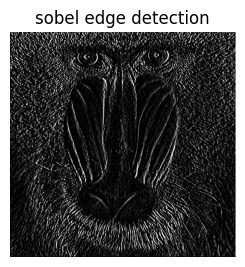

In [15]:
kernel_sobel = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
])

hasil_sobel = convolution2d(
    img_gray,
    kernel_sobel,
    1,
    1
)

hasil_sobel = np.clip(hasil_sobel, 0, 255).astype(np.uint8)

plt.subplot(1, 2, 2)
plt.imshow(hasil_sobel, cmap="gray")
plt.title("sobel edge detection")
plt.axis("off")

plt.show()

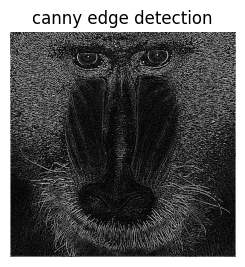

In [17]:
kernel_canny = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
])

hasil_canny = convolution2d(
    img_gray,
    kernel_canny,
    1,
    1
)

hasil_canny = np.clip(hasil_canny, 0, 255).astype(np.uint8)

plt.subplot(1, 2, 2)
plt.imshow(hasil_canny, cmap="gray")
plt.title("canny edge detection")
plt.axis("off")

plt.show()

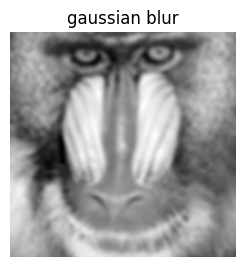

In [18]:

sigma = math.sqrt(21)
gaussian_kernel = cv.getGaussianKernel(21, sigma)

gauss_kernel = gaussian_kernel @ gaussian_kernel.T
hasil_gaussian = convolution2d(
    img_gray,
    gauss_kernel,
    1,
    1
)

plt.subplot(1, 2, 2)
plt.imshow(hasil_gaussian, cmap="gray")
plt.title("gaussian blur")
plt.axis("off")

plt.show()

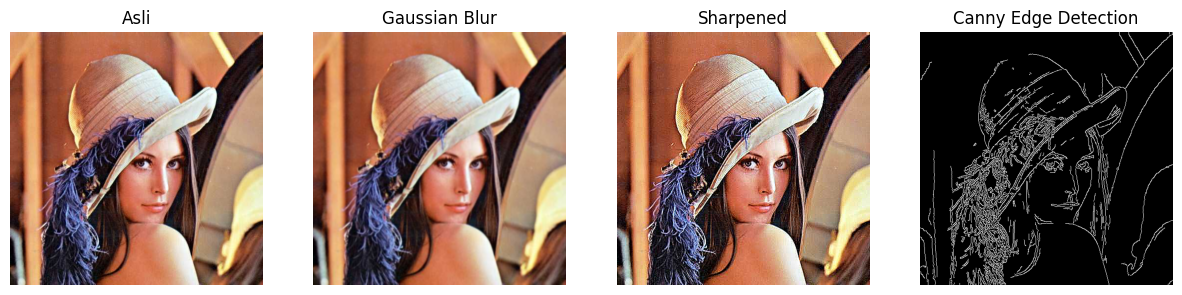

In [20]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/coolyeah /PCVK/lena.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

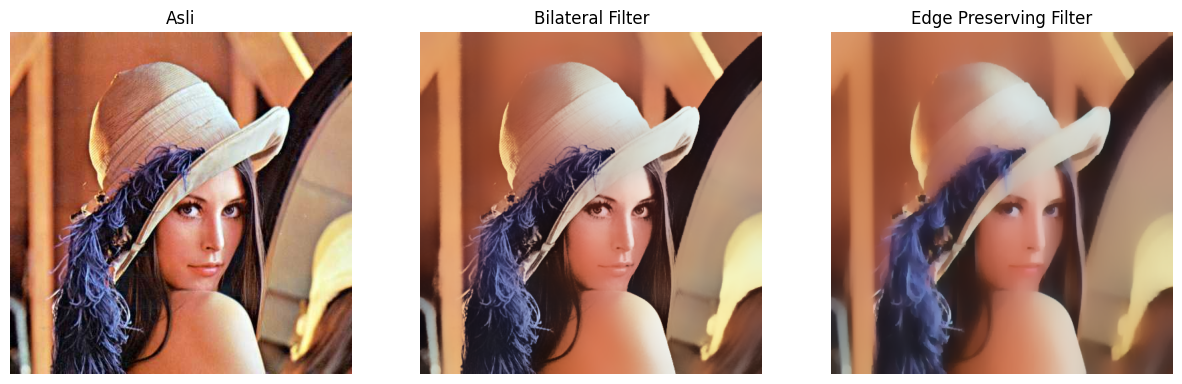

In [21]:
bilateral = cv.bilateralFilter(img, 50,100, 100)

edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])


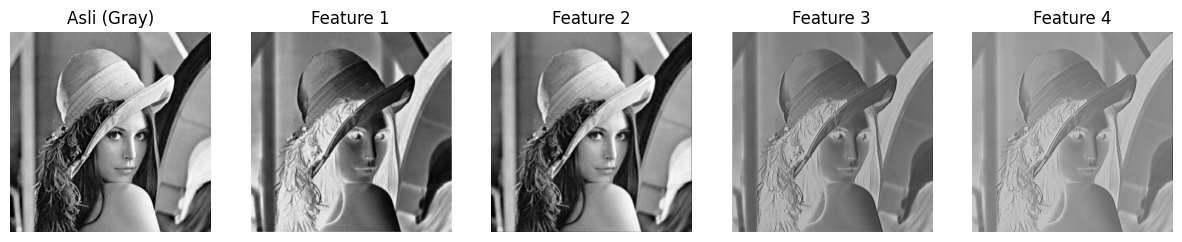

In [24]:
#Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

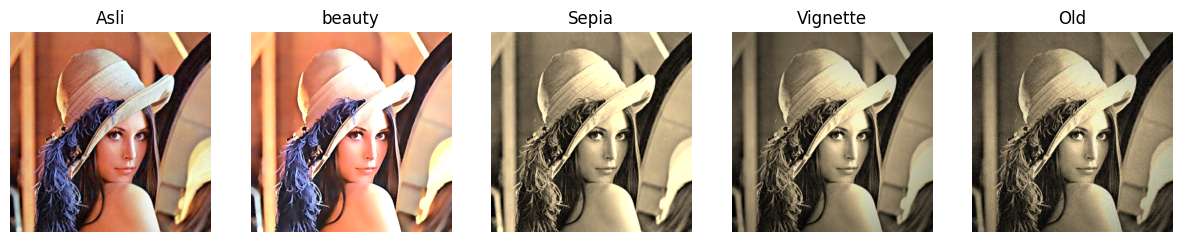

In [27]:
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

alpha = 1.2
beta = 15
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, sepia, vignette, old_img],
                  ["Asli", "beauty", "Sepia", "Vignette", "Old"])

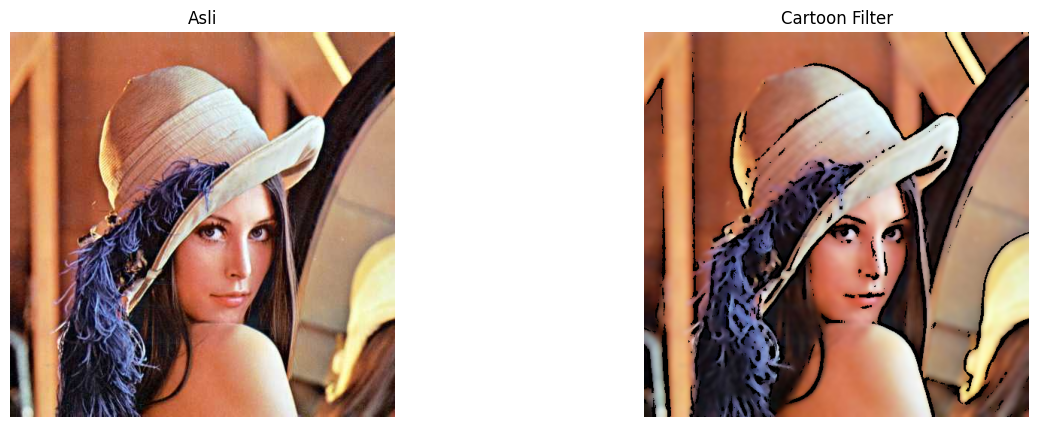

In [28]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

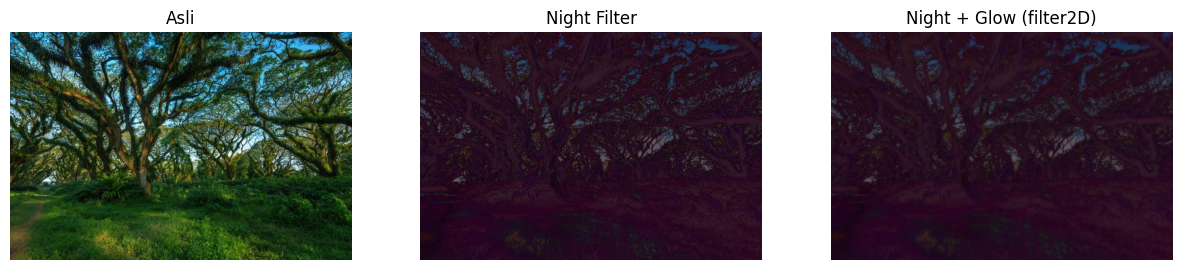

In [29]:
img = cv.imread("/content/drive/MyDrive/coolyeah /PCVK/djawatan.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

blue_tint = np.full_like(night, (50, 0, 100))
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

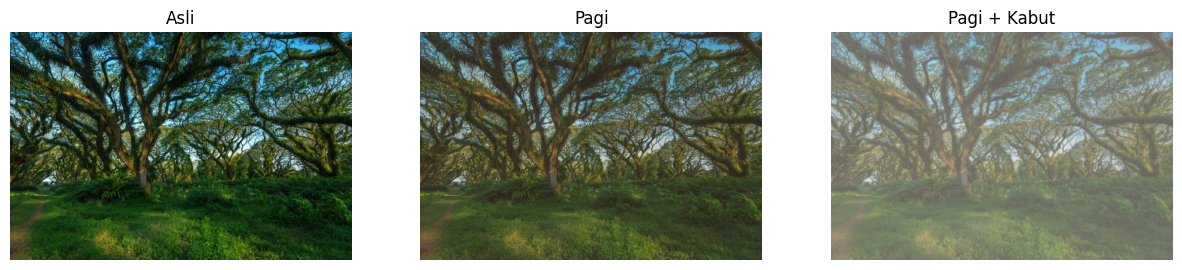

In [30]:
alpha = 0.9
beta = 20
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

warm_tint = np.full_like(soft, (40, 70, 120))
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T
kabut = cv.filter2D(pagi, -1, kernel)

white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

Tugas

In [37]:
import cv2 as cv
import numpy as np

image= cv.imread('/content/drive/MyDrive/coolyeah /PCVK/lena.jpg')
img_gray2 = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

def add_salt_pepper_noise(image, amount=0.05):
    noisy = image.copy()

    # Jumlah pixel yang diberi noise
    num_pixels = int(amount * image.size)

    # Salt - putih
    coords = np.random.randint(0, image.shape[0], num_pixels), \
             np.random.randint(0, image.shape[1], num_pixels)
    noisy[coords] = 255

    # Pepper - hitam
    coords = np.random.randint(0, image.shape[0], num_pixels), \
             np.random.randint(0, image.shape[1], num_pixels)
    noisy[coords] = 0

    return noisy

In [38]:
img_noisy = add_salt_pepper_noise(img_gray2, 0.05)

In [39]:
mean_filter = np.ones((3, 3), np.float32) / 9

hasil_mean = convolution2d(
    img_noisy,
    mean_filter,
    1,
    1
)

hasil_mean = np.clip(hasil_mean, 0, 255).astype(np.uint8)

In [40]:
hasil_median = cv.medianBlur(img_noisy, 3)

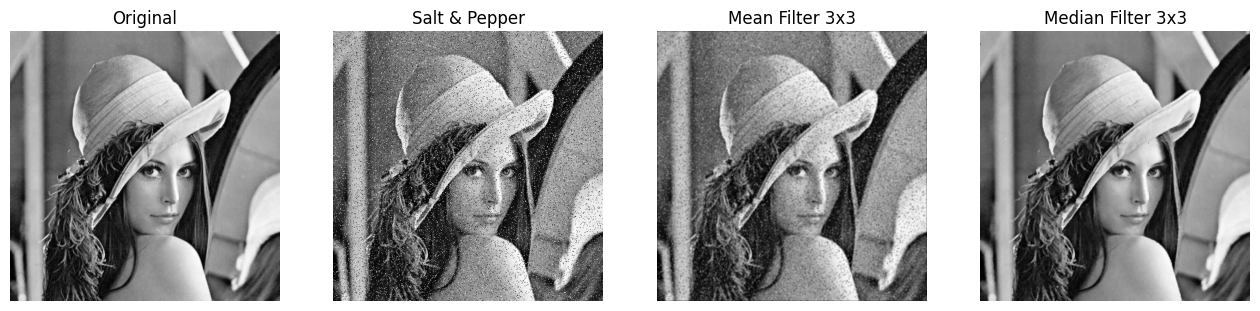

In [41]:
show_side_by_side(
    [
        img_gray2,
        img_noisy,
        hasil_mean,
        hasil_median
    ],
    [
        "Original",
        "Salt & Pepper",
        "Mean Filter 3x3",
        "Median Filter 3x3"
    ],
    figsize=(16, 5)
)

nilai pixel diurutkan, lalu diambil nilai tengahnya. Jadi bintik hitam/putih yang cuma sedikit tidak ikut memengaruhi hasil.

In [42]:
kernel_sharpen_3 = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

In [43]:
kernel_sharpen_5 = np.array([
    [ 0,  0, -1,  0,  0],
    [ 0, -1, -1, -1,  0],
    [-1, -1, 17, -1, -1],
    [ 0, -1, -1, -1,  0],
    [ 0,  0, -1,  0,  0]
])

In [44]:
img_blur = cv.GaussianBlur(img_gray2, (5, 5), 0)

In [45]:
hasil_sharpen_3 = convolution2d(
    img_blur,
    kernel_sharpen_3,
    1,
    1
)

hasil_sharpen_3 = np.clip(
    hasil_sharpen_3, 0, 255
).astype(np.uint8)

In [46]:
hasil_sharpen_5 = convolution2d(
    img_blur,
    kernel_sharpen_5,
    1,
    2
)

hasil_sharpen_5 = np.clip(
    hasil_sharpen_5, 0, 255
).astype(np.uint8)

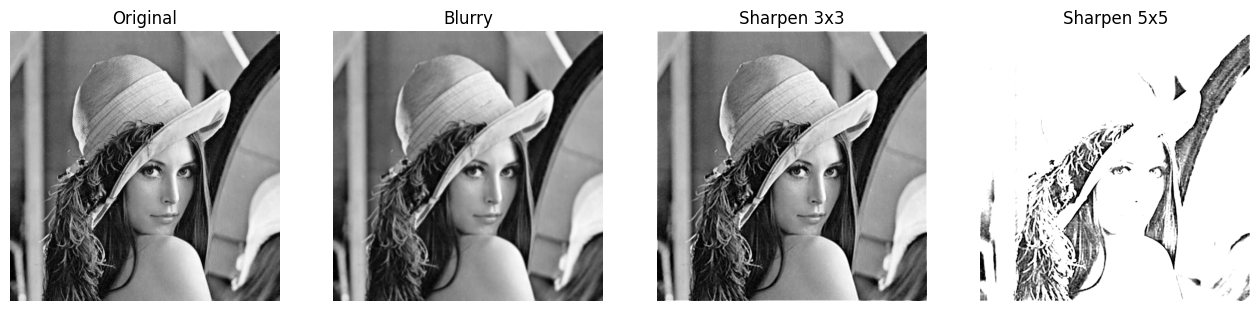

In [47]:
show_side_by_side(
    [
        img_gray2,
        img_blur,
        hasil_sharpen_3,
        hasil_sharpen_5
    ],
    [
        "Original",
        "Blurry",
        "Sharpen 3x3",
        "Sharpen 5x5"
    ],
    figsize=(16, 5)
)

untuk aspek kejelasan 3x3 lebih baik. 5x5 terlalu terang

kernel untuk sehari2 mending 3x3

In [48]:
def kartun(image):
    smooth = cv.bilateralFilter(
        image,
        d=9,
        sigmaColor=75,
        sigmaSpace=75
    )

    gray = cv.cvtColor(smooth, cv.COLOR_BGR2GRAY)

    edges = cv.Canny(
        gray,
        100,
        200
    )

    edges = cv.bitwise_not(edges)

    edges = cv.cvtColor(
        edges,
        cv.COLOR_GRAY2BGR
    )

    cartoon_image = cv.bitwise_and(
        smooth,
        edges
    )

    return cartoon_image

In [49]:
img = cv.imread("/content/drive/MyDrive/coolyeah /PCVK/lena.jpg")

hasil_kartun = kartun(img)

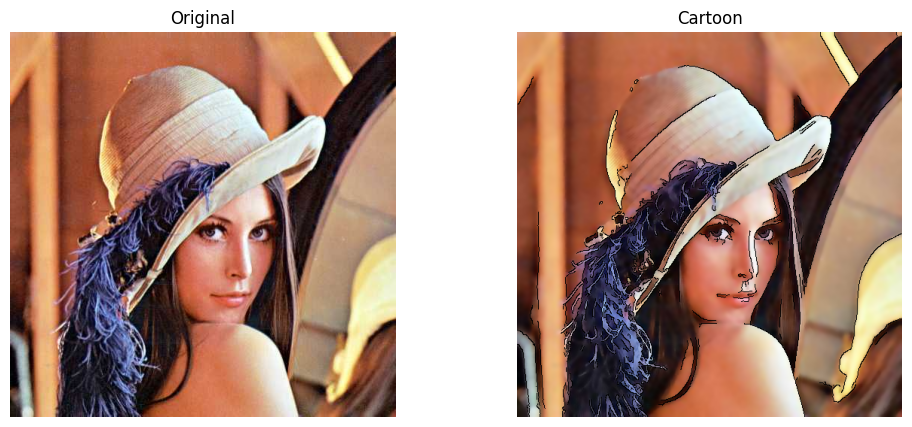

In [50]:
show_side_by_side(
    [
        img,
        hasil_kartun
    ],
    [
        "Original",
        "Cartoon"
    ],
    figsize=(12, 5)
)